# Histórico sobre os tipos de dados de séries temporais
![img](https://miro.medium.com/max/1400/1*V_RKPeIxCB9CS_2SsLyKXw.jpeg)

In [8]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


DEPRECATION: Loading egg at c:\programdata\anaconda3\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation.. Discussion can be found at https://github.com/pypa/pip/issues/12330


In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Dados
Os dados que usaremos são dados de consumo de energia por hora da PJM. O consumo de energia tem algumas características exclusivas. Será interessante ver como o profeta as capta.
 
Puxando o `PJM East`, que tem dados de 2002 a 2018 para toda a região leste.

In [19]:
pjme = pd.read_csv('./PJME_hourly.csv',
                   index_col=[0],
                  parse_dates=[0])
pjme.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


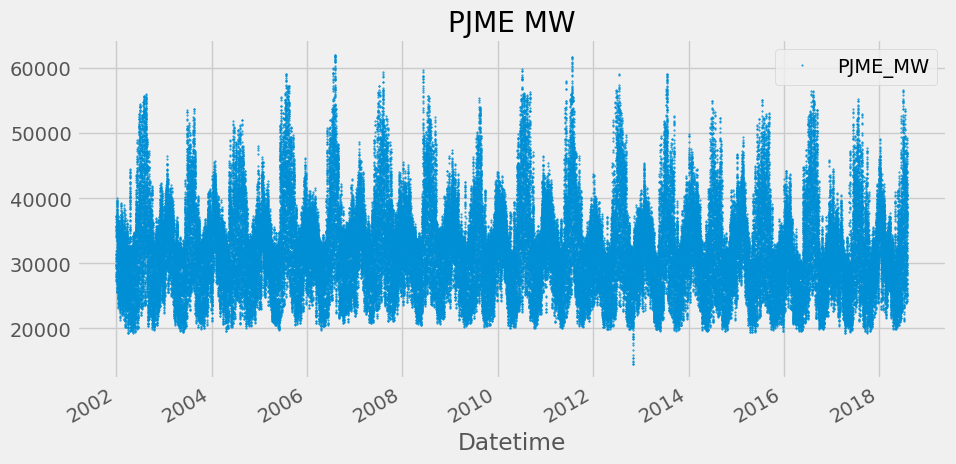

In [21]:
color_pal = sns.color_palette()
pjme.plot(style='.',
          figsize=(10, 5),
          ms=1,
          color=color_pal[0],
          title='PJME MW')
plt.show()

# Recursos de séries temporais

In [31]:
from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(categories=['Monday','Tuesday',
                                        'Wednesday',
                                        'Thursday','Friday',
                                        'Saturday','Sunday'],
                            ordered=True)

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300], 
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    X = df[['hour','dayofweek','quarter','month','year',
           'dayofyear','dayofmonth','weekday',
           'season']]
    if label:
        y = df[label]
        return X, y
    return X

X, y = create_features(pjme, label='PJME_MW')
features_and_target = pd.concat([X, y], axis=1)

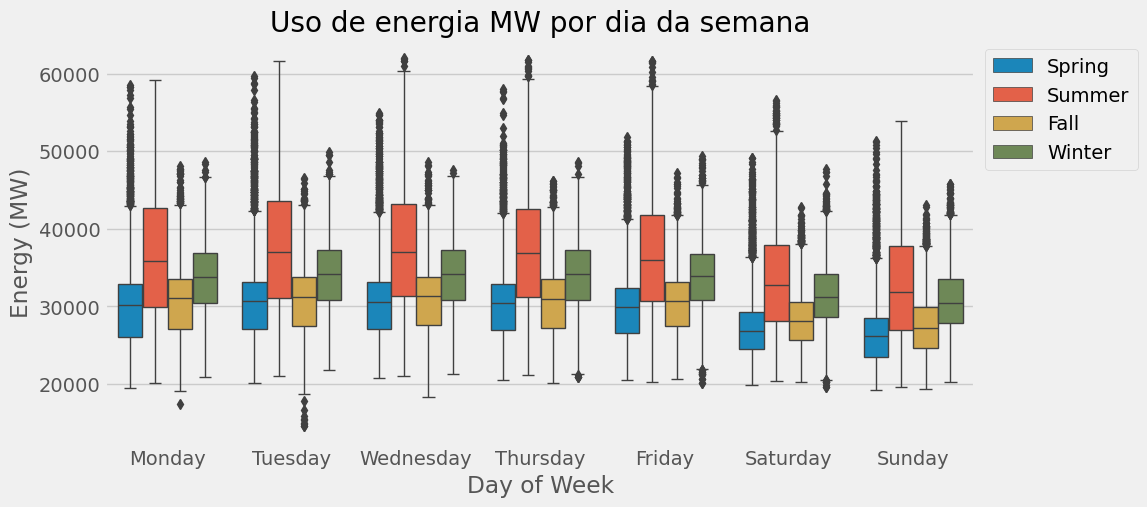

In [125]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=features_and_target.dropna(),
            x='weekday',
            y='PJME_MW',
            hue='season',
            ax=ax,
            linewidth=1)
ax.set_title('Uso de energia MW por dia da semana')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Energy (MW)')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

# Train / Test Split

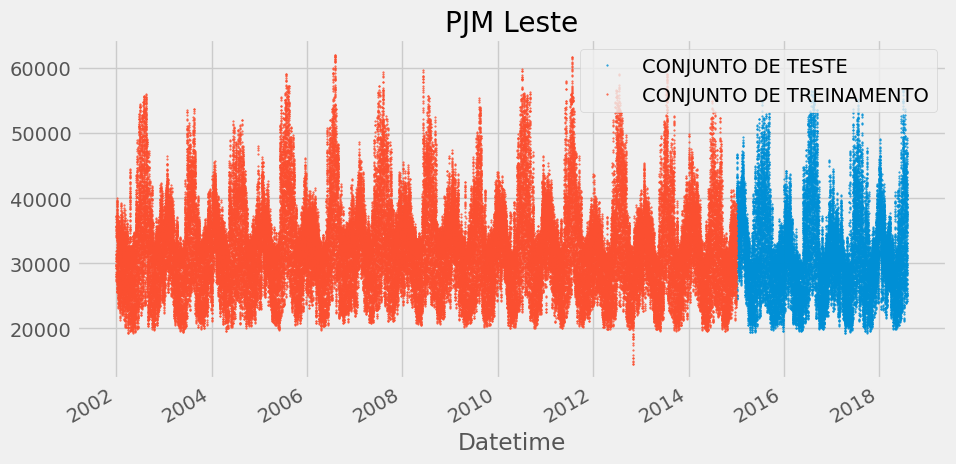

In [123]:
split_date = '1-Jan-2015'
pjme_train = pjme.loc[pjme.index <= split_date].copy()
pjme_test = pjme.loc[pjme.index > split_date].copy()

pjme_test \
    .rename(columns={'PJME_MW': 'CONJUNTO DE TESTE'}) \
    .join(pjme_train.rename(columns={'PJME_MW': 'CONJUNTO DE TREINAMENTO'}),
          how='outer') \
    .plot(figsize=(10, 5), title='PJM Leste', style='.', ms=1)
plt.show()

# Modelo simples do Prophet
- O modelo Prophet espera que o conjunto de dados seja nomeado de uma maneira específica. Vamos renomear as colunas do nosso dataframe antes de inseri-lo no modelo.
    - Coluna de data e hora nomeada: `ds`
    - destino: `y`

In [37]:
# Format data for prophet model using ds and y
pjme_train_prophet = pjme_train.reset_index() \
    .rename(columns={'Datetime':'ds',
                     'PJME_MW':'y'})

In [39]:
%%time
model = Prophet()
model.fit(pjme_train_prophet)

20:51:42 - cmdstanpy - INFO - Chain [1] start processing
20:53:12 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 7.45 s
Wall time: 1min 42s


In [40]:
# Predict on test set with model
pjme_test_prophet = pjme_test.reset_index() \
    .rename(columns={'Datetime':'ds',
                     'PJME_MW':'y'})

pjme_test_fcst = model.predict(pjme_test_prophet)

In [41]:
pjme_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31200.339206,23701.113046,33122.451838,31200.339206,31200.339206,-2842.562168,-2842.562168,-2842.562168,-4430.590454,...,1281.474328,1281.474328,1281.474328,306.553958,306.553958,306.553958,0.0,0.0,0.0,28357.777038
1,2015-01-01 02:00:00,31200.300721,22687.237747,31715.711868,31200.300721,31200.300721,-4347.079710,-4347.079710,-4347.079710,-5927.617356,...,1272.694228,1272.694228,1272.694228,307.843418,307.843418,307.843418,0.0,0.0,0.0,26853.221011
2,2015-01-01 03:00:00,31200.262235,21839.643435,30518.362351,31200.262235,31200.262235,-5218.803832,-5218.803832,-5218.803832,-6790.687108,...,1262.708907,1262.708907,1262.708907,309.174370,309.174370,309.174370,0.0,0.0,0.0,25981.458403
3,2015-01-01 04:00:00,31200.223749,21628.897122,30131.142092,31200.223749,31200.223749,-5360.281813,-5360.281813,-5360.281813,-6922.470785,...,1251.642133,1251.642133,1251.642133,310.546839,310.546839,310.546839,0.0,0.0,0.0,25839.941936
4,2015-01-01 05:00:00,31200.185263,22085.248385,31113.987678,31200.185263,31200.185263,-4685.843322,-4685.843322,-4685.843322,-6237.434051,...,1239.629878,1239.629878,1239.629878,311.960851,311.960851,311.960851,0.0,0.0,0.0,26514.341942


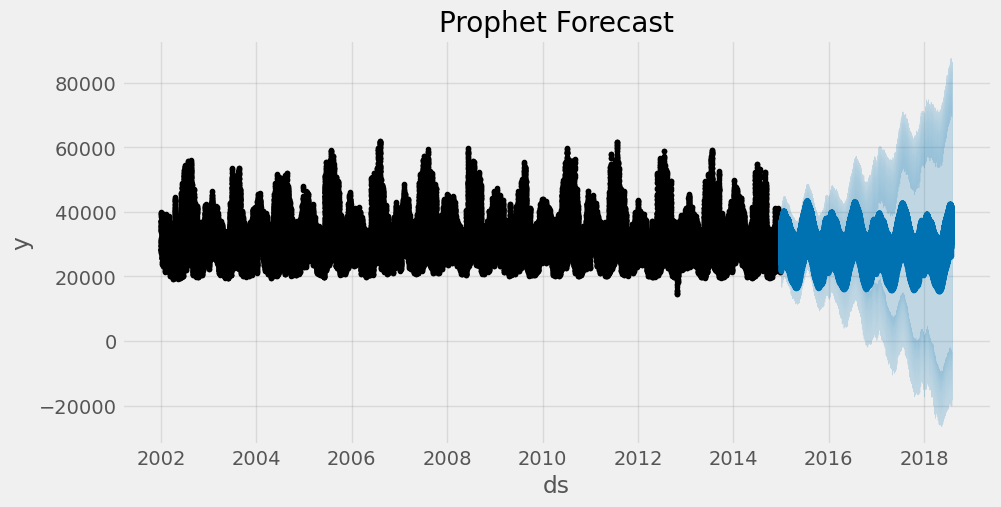

In [96]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

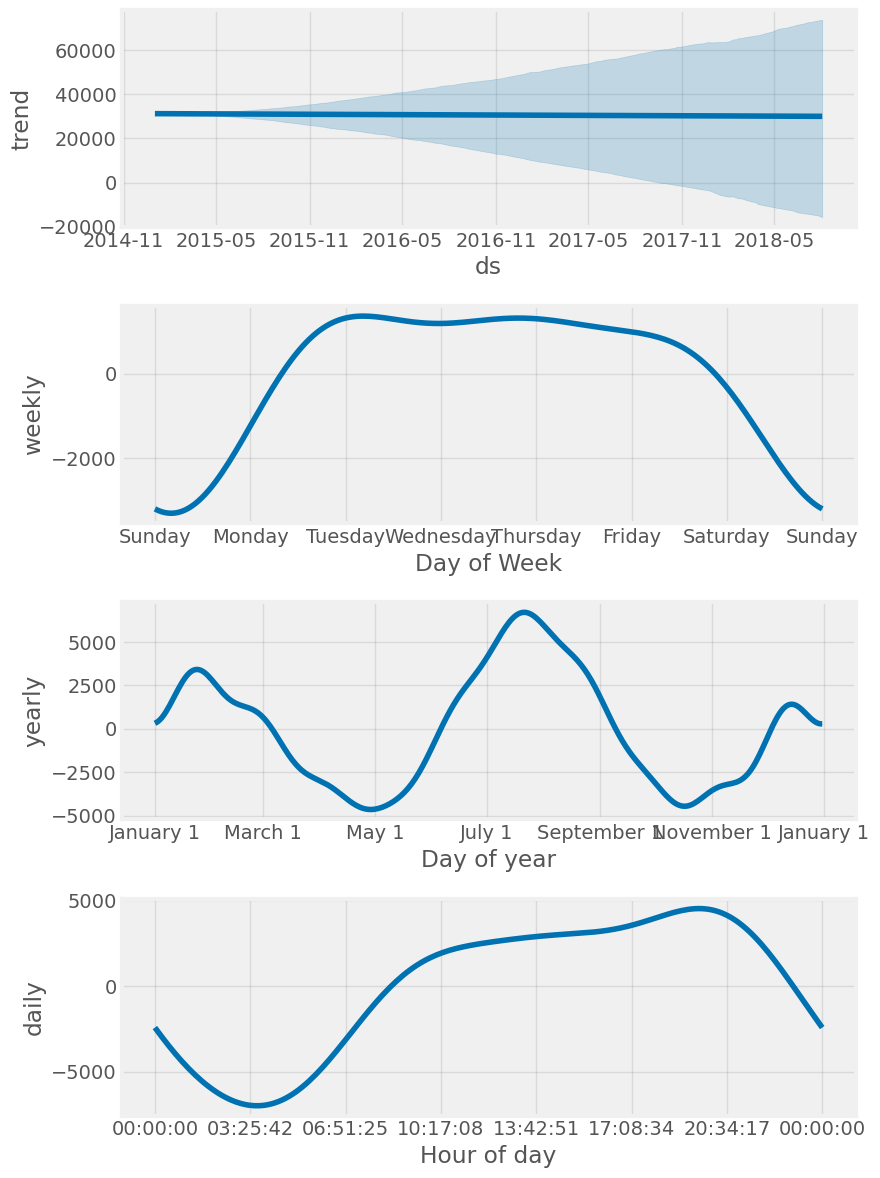

In [43]:
fig = model.plot_components(pjme_test_fcst)
plt.show()

# Compare a previsão com os dados reais

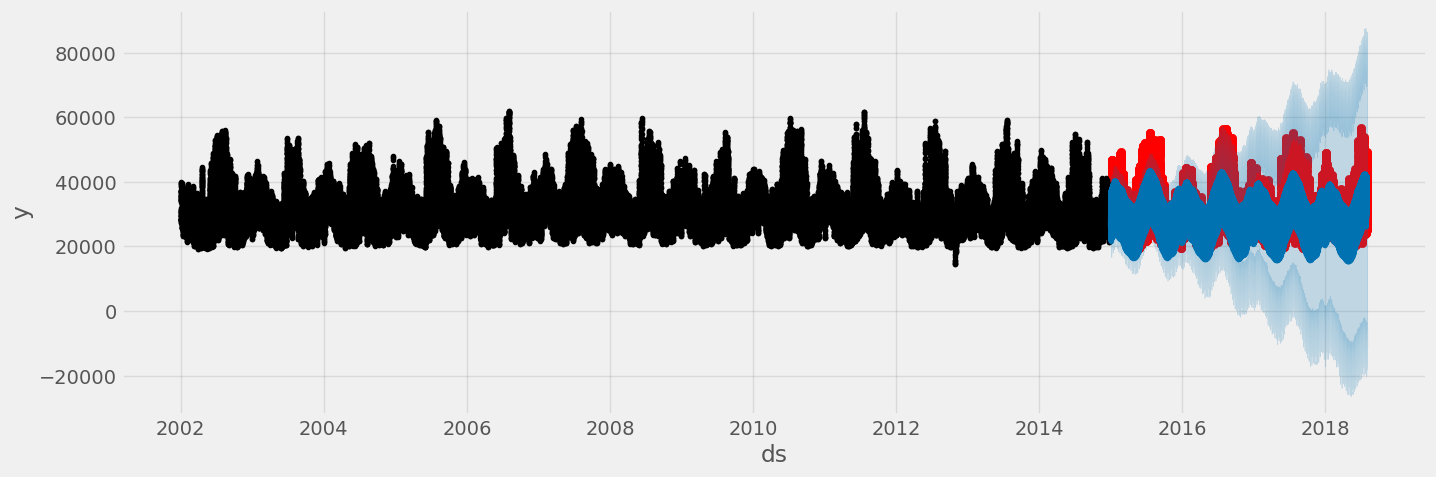

In [44]:
# Plot a previsão com os dados reais
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst, ax=ax)

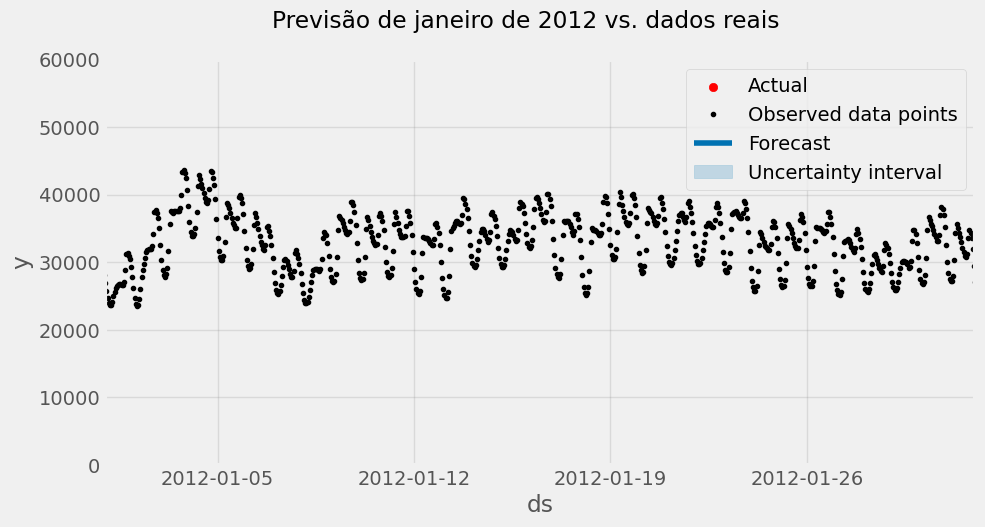

In [118]:
# Defina seus limites de data como objetos de data e hora
start_date = datetime.strptime('2012-01-01', '%Y-%m-%d')
end_date = datetime.strptime('2012-02-01', '%Y-%m-%d')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r', label='Actual')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xlim([start_date, end_date])
ax.set_ylim(0, 60000)
plt.suptitle('Previsão de janeiro de 2012 vs. dados reais')
ax.legend()
plt.show()

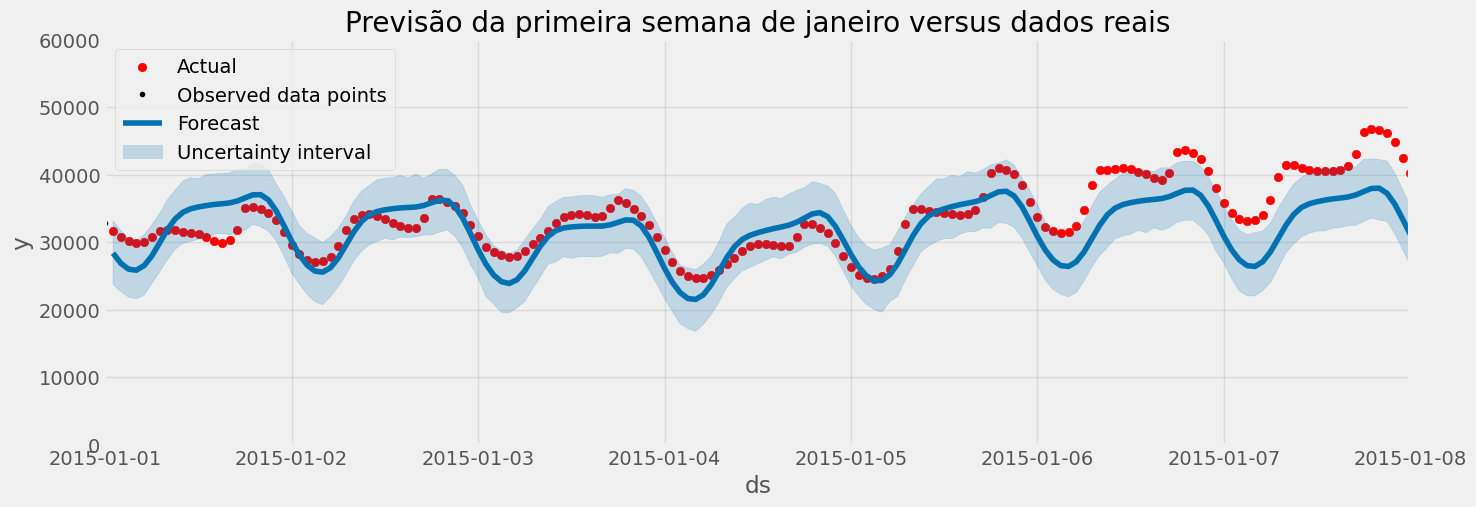

In [116]:
start_date = datetime.strptime('2015-01-01', '%Y-%m-%d')
end_date = datetime.strptime('2015-01-08', '%Y-%m-%d')


fig, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r', label='Actual')
fig = model.plot(pjme_test_fcst, ax=ax)
ax.set_xlim(start_date, end_date)
ax.set_ylim(0, 60000)
ax.set_title('Previsão da primeira semana de janeiro versus dados reais')
ax.legend()
plt.show()

# Avalie o modelo com métricas de erro

In [113]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst['yhat']))

6619.0084438739295

In [56]:
mean_absolute_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst['yhat'])

5183.308123570645

In [58]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst['yhat'])

16.505469633679194

# Adição de feriados

Em seguida, veremos se a adição de indicadores de feriados ajudará a precisão do modelo. O Prophet vem com um parâmetro Holiday Effects que pode ser fornecido ao modelo antes do treinamento.

Usaremos o pandas USFederalHolidayCalendar incorporado para obter a lista de feriados

In [60]:
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

cal = calendar()


holidays = cal.holidays(start=pjme.index.min(),
                        end=pjme.index.max(),
                        return_name=True)
holiday_df = pd.DataFrame(data=holidays,
                          columns=['holiday'])
holiday_df = holiday_df.reset_index().rename(columns={'index':'ds'})

In [62]:
%%time
model_with_holidays = Prophet(holidays=holiday_df)
model_with_holidays.fit(pjme_train_prophet)

21:01:38 - cmdstanpy - INFO - Chain [1] start processing
21:03:56 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 6.8 s
Wall time: 2min 33s


In [63]:
# Prever no conjunto de treinamento com o modelo
pjme_test_fcst_with_hols = \
    model_with_holidays.predict(df=pjme_test_prophet)

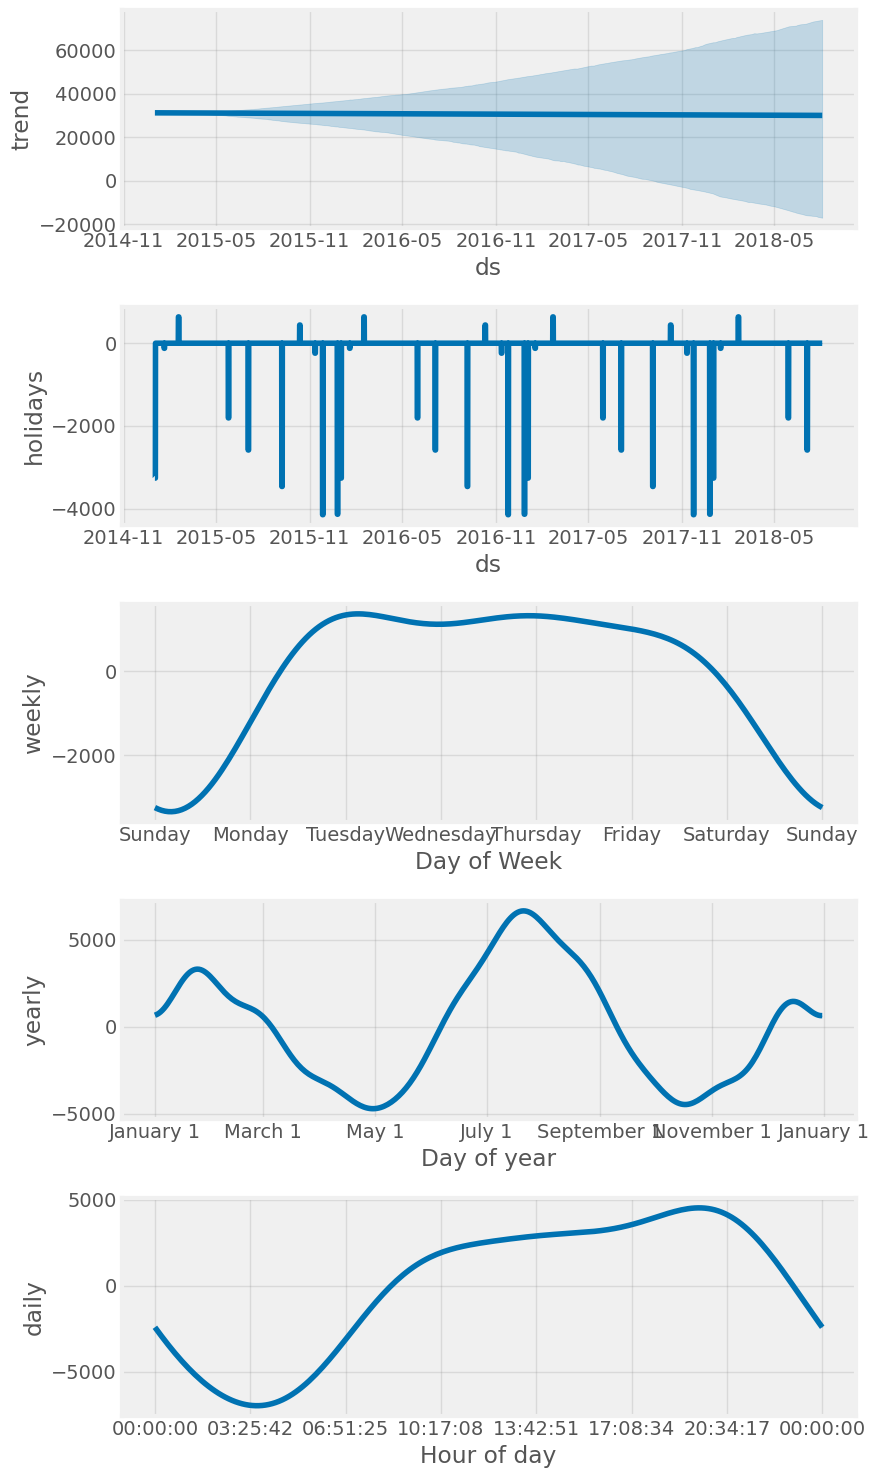

In [64]:
fig = model_with_holidays.plot_components(
    pjme_test_fcst_with_hols)
plt.show()

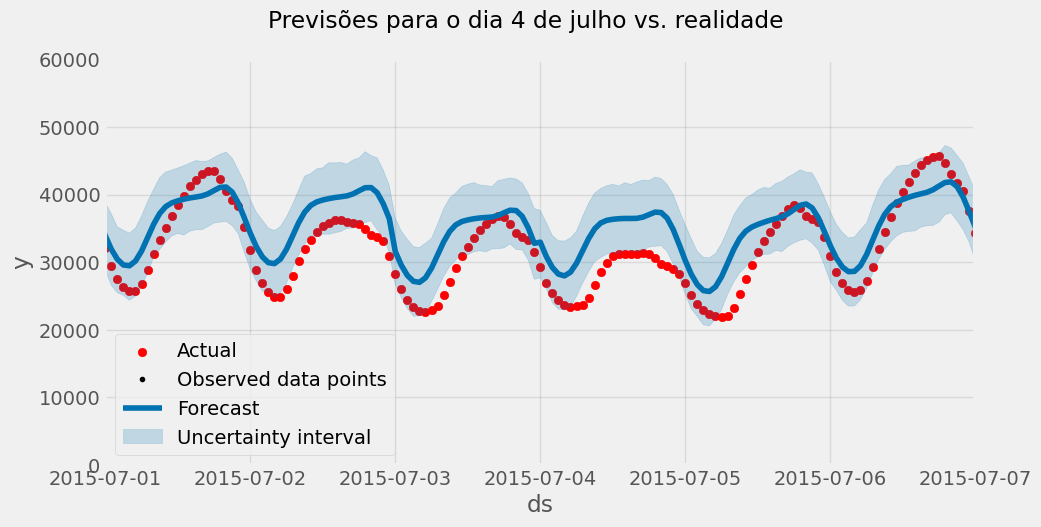

In [111]:
start_date = datetime.strptime('2015-07-01', '%Y-%m-%d')
end_date = datetime.strptime('2015-07-07', '%Y-%m-%d')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r', label='Actual')
fig = model.plot(pjme_test_fcst_with_hols, ax=ax)
ax.set_xlim(start_date, end_date)
ax.set_ylim(0, 60000)
plt.suptitle('Previsões para o dia 4 de julho vs. realidade')
ax.legend()
plt.show()

In [100]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst_with_hols['yhat']))

6635.663701334185

In [102]:
mean_absolute_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst_with_hols['yhat'])

5198.953628812672

In [104]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst_with_hols['yhat'])

16.56269753572198

# Prever o futuro

Podemos usar o método `make_future_dataframe` incorporado para criar nosso dataframe futuro e fazer previsões.

In [106]:
future = model.make_future_dataframe(periods=365*24, freq='h', include_history=False)
forecast = model_with_holidays.predict(future)

In [107]:
forecast[['ds','yhat']].head()

,ds,yhat
0,2015-01-01 01:00:00,25537.447405
1,2015-01-01 02:00:00,24035.495631
2,2015-01-01 03:00:00,23165.961037
3,2015-01-01 04:00:00,23026.348547
4,2015-01-01 05:00:00,23702.320333
